In [17]:
import os, sys

PROJECT_ROOT = r"E:\Pranav\Engineering\Projects\AEWS"
os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [18]:
import pandas as pd

# Load processed data
isi_df = pd.read_csv("data/processed/isi_scores.csv")
lifecycle_df = pd.read_csv("data/processed/lifecycle_clusters.csv")

# Merge into one AEWS table
df = isi_df.merge(
    lifecycle_df[["state", "district", "year_month", "lifecycle_cluster"]],
    on=["state", "district", "year_month"],
    how="left"
)

# Sort for temporal logic
df = df.sort_values(["state", "district", "year_month"]).reset_index(drop=True)

print("df shape:", df.shape)
df.head()


df shape: (12004, 11)


,state,district,year_month,enrol_activity,demo_activity,bio_activity,enrol_norm,demo_norm,bio_norm,isi_score,lifecycle_cluster
0,100000,100000,2025-02,100003,200002,14139195,6.364787e-10,0.000019,0.003578,0.001439,0
1,100000,100000,2025-03,100001,11161793,12649948,0.000000e+00,0.002297,0.003198,0.002198,0
2,100000,100000,2025-08,100001,9673377,9673415,0.000000e+00,0.001988,0.002439,0.001771,0
3,100000,100000,2025-09,100001,13393929,7441171,0.000000e+00,0.002761,0.001870,0.001852,0
4,100000,100000,2025-11,100002,14882372,12650221,3.182393e-10,0.003070,0.003198,0.002507,0


In [19]:
# Percentile-based risk definition
low_cut = df["isi_score"].quantile(0.70)
high_cut = df["isi_score"].quantile(0.90)

def label_risk(isi):
    if isi <= low_cut:
        return 0
    elif isi <= high_cut:
        return 1
    else:
        return 2

df["risk_label"] = df["isi_score"].apply(label_risk)

# Shift to next month (EARLY WARNING TARGET)
df["risk_label_next"] = (
    df.groupby(["state", "district"])["risk_label"]
      .shift(-1)
)

df = df.dropna(subset=["risk_label_next"])
df["risk_label_next"] = df["risk_label_next"].astype(int)

df[["year_month", "risk_label", "risk_label_next"]].head()


,year_month,risk_label,risk_label_next
0,2025-02,0,0
1,2025-03,0,0
2,2025-08,0,0
3,2025-09,0,0
4,2025-11,0,0


In [20]:
from src.models.risk_classifier import RiskClassifier
from sklearn.model_selection import train_test_split

feature_cols = [
    "enrol_norm",
    "demo_norm",
    "bio_norm",
    "lifecycle_cluster"
]

X = df[feature_cols]
y = df["risk_label_next"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

classifier = RiskClassifier()
classifier.train(X_train, y_train)

print("✔ Model trained")


✔ Model trained


In [21]:
from sklearn.model_selection import train_test_split
from src.models.risk_classifier import RiskClassifier

feature_cols = [
    "enrol_norm",
    "demo_norm",
    "bio_norm",
    "lifecycle_cluster"
]

X = df[feature_cols]
y = df["risk_label_next"]

print(X.shape, y.shape)
y.value_counts()


(10959, 4) (10959,)


risk_label_next
0    7687
1    2210
2    1062
Name: count, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

classifier = RiskClassifier()
classifier.train(X_train, y_train)

print("✔ Model trained and ready for SHAP")


✔ Model trained and ready for SHAP


In [23]:
import shap

explainer = shap.TreeExplainer(classifier.model)


In [24]:
# Select first high-risk row as a DataFrame (1 row only)
high_risk_row = X[df["risk_label_next"] == 2].iloc[[0]]

high_risk_row


,enrol_norm,demo_norm,bio_norm,lifecycle_cluster
65,0.005264,0.004153,0.005475,0


In [25]:
shap_values = explainer.shap_values(high_risk_row)


In [26]:
import pandas as pd
import numpy as np

# Handle multiclass SHAP safely
if isinstance(shap_values, list):
    # List[n_classes][n_samples][n_features]
    values = shap_values[2][0]
else:
    # Array[n_samples][n_features][n_classes]
    values = shap_values[0][:, 2]

explanation = pd.DataFrame({
    "feature": feature_cols,
    "impact": values
}).sort_values("impact", key=abs, ascending=False)

explanation


,feature,impact
2,bio_norm,0.132072
1,demo_norm,0.066152
0,enrol_norm,-0.002076
3,lifecycle_cluster,0.000448


In [27]:
from src.explainability.plain_english_report import generate_explanation

text_report = generate_explanation(explanation)
text_report


'Biometric update activity is unusually high, increasing authentication pressure. Demographic update requests have increased, indicating identity corrections or migration.'

In [30]:
import os
os.makedirs("outputs/visuals", exist_ok=True)

from src.visuals.sankey_builder import build_lifecycle_sankey

fig = build_lifecycle_sankey(df)
fig.write_html("outputs/visuals/identity_lifecycle_sankey.html")

print("✔ Enhanced Sankey saved")


✔ Enhanced Sankey saved


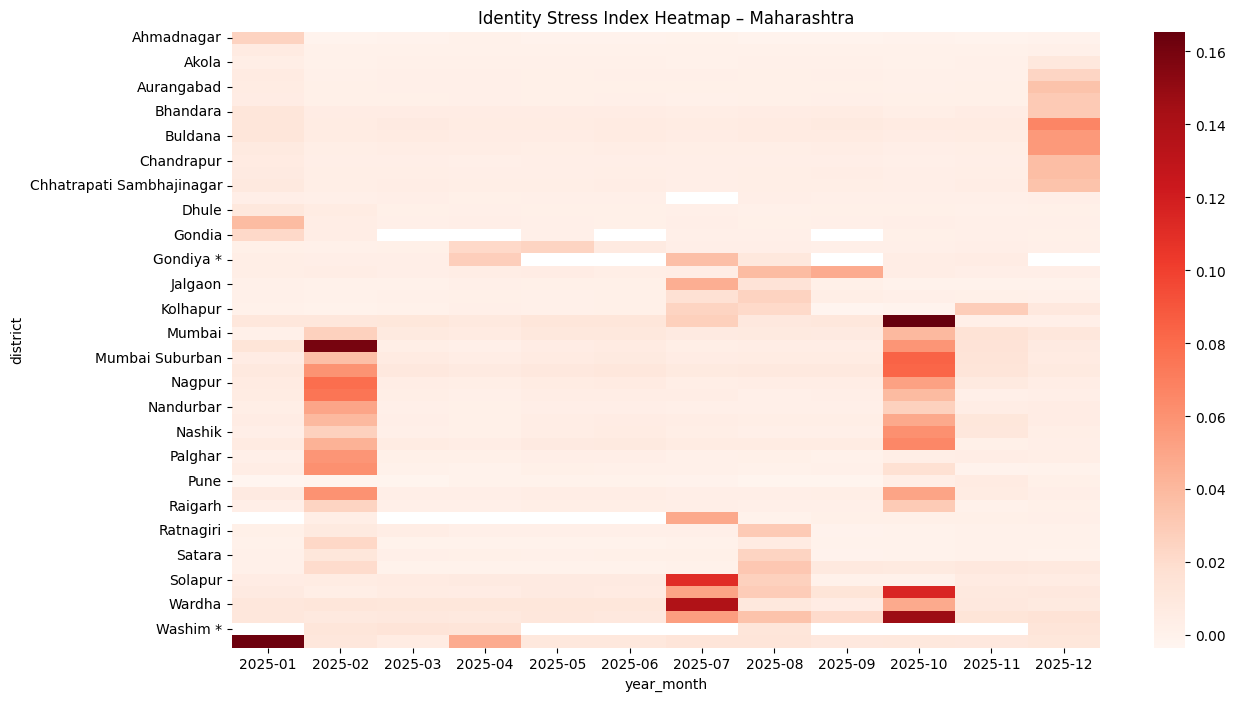

In [29]:
from src.visuals.isi_heatmap import plot_isi_heatmap
plot_isi_heatmap(df, state_name="Maharashtra")
